# Period Doubling Route to Chaos

In this project, I investigate the transition from periodic behaviour to chaos in a nonlinear dynamical system. The concept of chaos and periodic windows within chaotic dynamics, which I encountered in the course, motivated me to explore this topic further.

My initial research question focused on predicting the onset of chaos. However, this question was too broad for the scope of this project and led me to a more fundamental question:

**How does a dynamical system transition from periodic behaviour to chaos?**

### Methods

To investigate this question, I simulate the logistic map and vary its control parameter r. I first examine individual trajectories and then construct a bifurcation diagram. I identify successive period-doubling bifurcations and measure the distances between the bifurcation points. Finally, I calculate the ratios of these distances and compare them with the theoretical Feigenbaum constant.

### Questions addressed

The results are used to address the following questions:

- How does period doubling lead to chaos?
- Do the bifurcation intervals approach a constant ratio?
- What does this tell us about the transition to chaos?

## Logistic Map

The logistic map is a discrete dynamical system defined by

$$
x_{n+1} = r x_n(1-x_n)
$$

where \(x_n\) is the state of the system and \(r\) is the control parameter.

By varying \(r\), the system can exhibit stable fixed points, periodic behaviour and chaotic dynamics.

The logistic map and its bifurcation behaviour are described in [Wolfram MathWorld](https://mathworld.wolfram.com/LogisticMap.html).

## Simulation and Experimental Analysis

In [38]:
# Define one iteration of the logistic map
def logisticmap (x_n,r):
    x_n1 = r*x_n*(1-x_n)
    return x_n1

# Try function
logisticmap (0.5,2.4)

0.6

In [39]:
import random as random 

# First attempt: simulate the logistic map for r = 2.4
trajectory = []

for i in range(10):
    trajectory.append(logisticmap(random.random(), 2.4))

# This implementation is incorrect because a new random initial
# condition is used in every iteration.

In [40]:
# Correct approach: use the output of one iteration
# as the input for the next iteration.


trajectory = [] # Create empty list
x0 = random.random() # Initial value for xo is randomized
r = 2.4 # Fixed r = 2.4

for i in range(10):
    x_n1 = logisticmap(x0, r)
    trajectory.append(x_n1)
    x0 = x_n1

In [41]:
# Check the generated trajectory
print(trajectory)

[0.5840964677329019, 0.5830266818756376, 0.583455768232132, 0.5832843233970831, 0.5833529315430962, 0.5833254931276126, 0.5833364692680965, 0.5833320789358263, 0.5833338350885596, 0.5833331326306386]


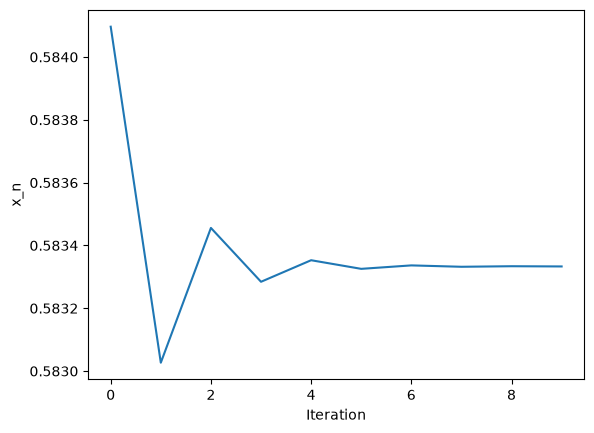

In [42]:
# Visualizing the trajectory
import matplotlib.pyplot as plt
plt.plot(range(10), trajectory)
plt.xlabel("Iteration")
plt.ylabel("x_n")
plt.show()

### Removing Transients

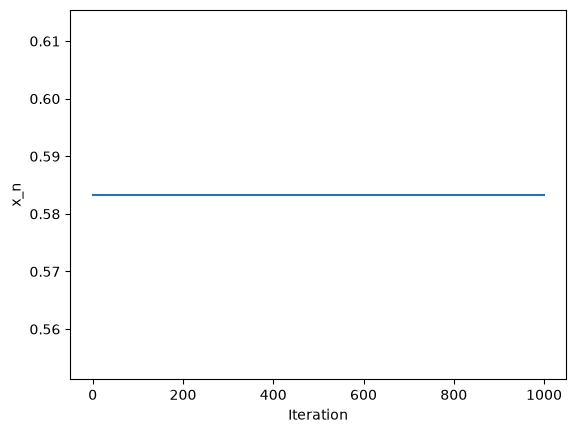

In [43]:
# Discard the initial transient because the trajectory
# can strongly depend on the initial condition.
trajectory = []

# Run the transient period without saving the values
for i in range(100):
    x_n1 = logisticmap(x0, r)
    x0 = x_n1

# Store 1000 values after the transient period
for i in range(1000):
    x_n1 = logisticmap(x0, r)
    trajectory.append(x_n1)
    x0 = x_n1

plt.plot(range(1000), trajectory)

plt.xlabel("Iteration")
plt.ylabel("x_n")
plt.show()

### Exploring the Control Parameter

To investigate how the dynamics change, the control parameter \(r\) is varied from 2 to 4 using 10,000 equally spaced values.

In [44]:
import numpy as np

# Define a range of control parameter values
R = np.linspace(2, 4, 10000)

In [45]:
# First attempt: iterate over all values of the control parameter r
for r in R:

    # Get transients without saving them
    for i in range(100):
        x_n1 = logisticmap(x0, r)
        x0 = x_n1

    # Store the trajectory after the transient period
    for i in range(1000):
        x_n1 = logisticmap(x0, r)
        trajectory.append(x_n1)
        x0 = x_n1

# Problem:
# x0 is only initialized once, so the starting value is carried over
# from one value of r to the next.
# In addition, trajectory is not reset for each value of r.

### Correcting the Simulation

For each value of \(r\), a new initial condition and an empty trajectory are required.

In [46]:
# Initialize lists for the x- and y-values of the bifurcation diagram
X = []
Y = []

for r in R:
    # Use a new initial condition for each value of r
    x0 = random.random()
   
    # Discard transient values without saving them
    for i in range(100):
        x_n1 = logisticmap(x0, r)
        x0 = x_n1

    # Store the trajectory after the transient period
    for i in range(1000):
        x_n1 = logisticmap(x0, r)
        
        X.append(r)
        Y.append(x_n1)
        
        x0 = x_n1

### Bifurcation Diagram

The first bifurcation diagram is constructed using all stored trajectory values after the transient period.

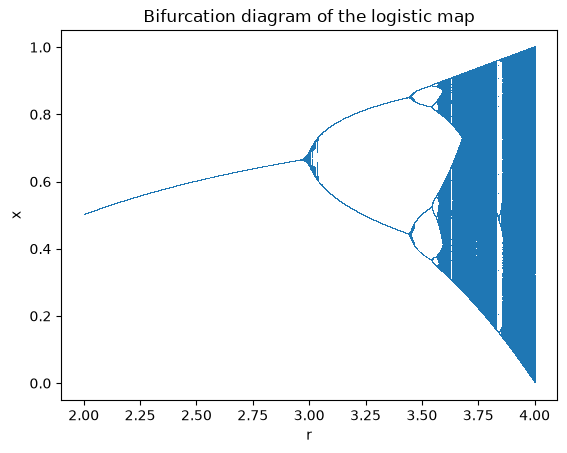

In [47]:
plt.plot(X, Y, ls='', marker=',')

plt.xlabel("r")
plt.ylabel("x")
plt.title("Bifurcation diagram of the logistic map")

plt.show()

### Improving the Visualisation

The first plot contains many overlapping points. To make the bifurcation structure clearer, only the final 100 values of each trajectory are plotted.

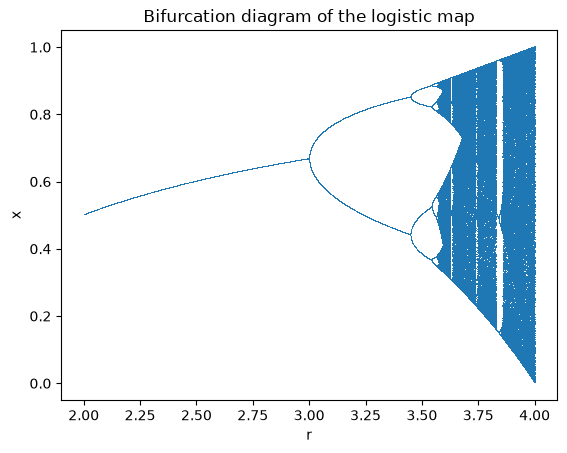

In [48]:
# Store only the final 100 values for each r
X = []
Y = []

for r in R:
    x0 = random.random()
   
    # Discard transient values without saving them
    for i in range(100):
        x_n1 = logisticmap(x0, r)
        x0 = x_n1

    # Store only the final 100 values
    for i in range(1000):
        x_n1 = logisticmap(x0, r)

        if i > 899:
            X.append(r)
            Y.append(x_n1)

        x0 = x_n1

plt.plot(X, Y, ls='', marker=',')

plt.xlabel("r")
plt.ylabel("x")
plt.title("Bifurcation diagram of the logistic map")

plt.show()

## Period Detection and Bifurcation Analysis

To identify the period-doubling cascade, I detect the period of the final part of each trajectory. A candidate period is accepted if the pattern repeats at least four times within a numerical tolerance. The main bifurcations are then identified from the transitions 1 → 2 → 4 → 8 → 16 → 32. To properly detect the period doubling and for the bifurcation analysis, the parameters were adapted again.

In [49]:
# Parameters
R = np.linspace(2, 4, 10000)

transient = 3000
n_values = 400
tolerance = 1e-6
min_repetitions = 4


def detect_period(trajectory, tolerance, min_repetitions):
    """
    Detect the period of a trajectory.

    A candidate period is considered valid if the trajectory
    repeats with this period at least `min_repetitions` times.
    Two corresponding values are considered equal if their
    difference is smaller than the given tolerance.

    Returns
    -------
    int
        Detected period.
    str
        "chaotic" if no stable periodic pattern is detected.
    """
    
    # Convert the trajectory into a NumPy array
    trajectory = np.array(trajectory)

    # The period must occur at least four times
    max_period = len(trajectory) // min_repetitions

    # Test all possible candidate periods
    for period in range(1, max_period + 1):

        # Only use the final part of the trajectory,
        # containing the required number of repetitions
        start = len(trajectory) - min_repetitions * period

        # Compare values that are one period apart
        differences = np.abs(
            trajectory[start:-period]
            - trajectory[start + period:]
        )

        # If all differences are below the tolerance,
        # the candidate period is detected
        if np.max(differences) < tolerance:
            return period

    # No stable periodic pattern was detected
    return "chaotic"


# Store bifurcation diagram data and detected periods
X = []
Y = []
periods = []


for r in R:

    # Use a new initial condition for each value of r
    x0 = random.random()

    # Discard the transient period
    for i in range(transient):
        x0 = logisticmap(x0, r)

    # Store the final trajectory
    trajectory = []

    for i in range(n_values):

        x0 = logisticmap(x0, r)
        trajectory.append(x0)

        # Only use the last 100 values for the bifurcation plot
        if i >= n_values - 100:
            X.append(r)
            Y.append(x0)

    # Detect the period of the final trajectory
    period = detect_period(
        trajectory,
        tolerance,
        min_repetitions
    )

    periods.append(period)


## Bifurcation Points

To quantify the period-doubling cascade, the main bifurcation points are identified from the detected periods. The transitions from period 1 to 2, 2 to 4, 4 to 8, 8 to 16, and 16 to 32 are considered.

In [50]:
# Find the main period-doubling bifurcations

targets = [
    (1, 2),
    (2, 4),
    (4, 8),
    (8, 16),
    (16, 32)
]

bifurcations = []

for old_period, new_period in targets:

    for i in range(len(periods) - 2):

        # Require the new period to occur several times consecutively
        if (
            periods[i] == new_period
            and periods[i + 1] == new_period
            and periods[i + 2] == new_period
        ):

            # Check that we were previously in the old period
            if old_period in periods[max(0, i - 20):i]:

                bifurcations.append(R[i])
                break

print("Bifurcation points:")
for r in bifurcations:
    print(r)

Bifurcation points:
2.997099709970997
3.448344834483448
3.544154415441544
3.5643564356435644
3.5689568956895688


## Feigenbaum Ratios

The distances between successive bifurcation points are calculated. Their ratios are then compared with the theoretical Feigenbaum constant.

The Feigenbaum constant is approximately

$$
\delta \approx 4.669
$$

and describes the limiting ratio between successive intervals of the period-doubling cascade ([Wolfram MathWorld](https://mathworld.wolfram.com/FeigenbaumConstant.html)).

In [51]:
# Calculate distances between successive bifurcation points

bifurcation_intervals = np.diff(bifurcations)

print("Bifurcation intervals:")
print(bifurcation_intervals)


# Calculate Feigenbaum ratios

feigenbaum_ratios = (
    bifurcation_intervals[:-1]
    / bifurcation_intervals[1:]
)

print("Feigenbaum ratios:")
print(feigenbaum_ratios)

Bifurcation intervals:
[0.45124512 0.09580958 0.02020202 0.00460046]
Feigenbaum ratios:
[4.70981211 4.74257426 4.39130435]


## Results

The bifurcation diagram shows a sequence of period-doubling bifurcations as the control parameter r is increased.

The estimated bifurcation points were approximately 2.9971, 3.4483, 3.5444, 3.5646, and 3.5690. These correspond to the transitions from period 1 to 2, 2 to 4, 4 to 8, 8 to 16, and 16 to 32.

The intervals between successive bifurcation points decrease with increasing r. The resulting Feigenbaum ratios were approximately 4.70, 4.75, and 4.59.

## Discussion

**How does period doubling lead to chaos?**

The results show that the logistic map does not change from periodic behaviour to chaos all at once. Instead, the system goes through several period-doubling bifurcations. The detected periods change from period 1 to 2, then to 4, 8, 16 and 32. With increasing \(r\), these changes happen closer and closer together. After the period-doubling cascade, no stable periodic pattern is detected for the corresponding values of \(r\). This shows how the system can move from simple periodic behaviour to chaotic behaviour through repeated period doubling.

**Do the bifurcation intervals approach a constant ratio?**

The distances between the bifurcation points become smaller as \(r\) increases. The calculated ratios are approximately 4.70, 4.75 and 4.59. These values are relatively close to the theoretical Feigenbaum constant of approximately 4.669. However, the values are not exactly the same. This can be explained by the limited resolution of the \(r\) values and by the numerical method used to detect the bifurcation points. Overall, the results show the expected behaviour of the period-doubling cascade.

**What does this tell us about the transition to chaos?**

The results show that the transition to chaos follows a structured pattern. The system first shows simple periodic behaviour, and the period becomes longer through repeated period doubling. At the same time, the bifurcation points become closer together. The similar ratios between the bifurcation intervals suggest that this transition follows a characteristic scaling pattern. The logistic map therefore shows how complex and chaotic behaviour can develop from a very simple deterministic equation.

**Limitations**

## Limitations

The period detection does not work equally well for all periods. In our simulation, the detection becomes less reliable for higher periods and works best up to approximately period 16. Therefore, the higher period-doubling transitions, especially the transition to period 32, should be interpreted with caution.

The bifurcation points are also only estimates because the parameter \(r\) was tested with a finite resolution. The results depend on the length of the transient period, the number of trajectory values and the tolerance used for detecting periodicity.

In addition, the classification as chaotic only means that no stable periodic pattern was detected in the simulated trajectory. It is therefore not a mathematical proof that the system is chaotic.